Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [1]:
NAME = "Ruilin Yang"
COLLABORATORS = ""

---

$$
\newcommand{\x}{\mathbf{x}}
\newcommand{\y}{\mathbf{y}}
\newcommand{\price}{{p}}
\newcommand{\ret}{{r}}
\newcommand{\tp}{{(t)}}
\newcommand{\aapl}{{\text{AAPL}}}
\newcommand{\ba}{{\text{BA}}}
\newcommand{\spy}{{\text{SPY}}}
$$

# Assignment: Using Machine Learning for Hedging

Welcome to the first assignment !

# Problem description

We will solve a Regression task that is very common in Finance

* Given the return of "the market", predict the return of a particular stock

That is

* Given the return of a proxy for "the market" at time $t$, predict the return of, e.g., Apple at time $t$.

As we will explain,
being able to predict the relationship between two financial instruments opens up possibilities

* Use one instrument to "hedge" or reduce the risk of holding the other
* Create strategies whose returns are independent of "the market"
  + Hopefully make a profit regardless of whether the market goes up or down

## Goal

You will create models of increasing complexity in order to explain the return of Apple (ticker $\aapl$)

* The first model will have a single feature: return of the market proxy, ticker $\spy$
* Subsequent models will add the return of other tickers as additional features

## Learning Objectives

* Learn how to solve a Regression task
* Become facile in the `sklearn` toolkit for Machine Learning

## How to report your answers

We will mix explanation of the topic with tasks that you must complete.

Look for
the string "**Question**" to find a task that you must perform.

Most of the tasks will require you to create some code at the location indicated by

> `# YOUR CODE HERE raise NotImplementedError()`

* Replace `raise NotImplementedError()` with your own code

# A word about the data

We are seeking the relationship between the daily returns of an equity and an index.

Because the unique identifier of an example is a date, you will naturally be inclined to think of
the dataset as a timeseries

For the purpose of this assignment: please ignore the fact that dates establish an ordering. Just treat a date as a unique id for the example that is devoid of meaning.

Instead, think of each example as an empirical observation of the relationship between an equity and an index.

* the observations happen to be identified by date
* you will not assume any ordering between examples
  + i.e., shuffling the examples will not change the meaning of the dataset

The reason:

Our current knowledge is that a feature is a *scalar* value. Some data types have "extra" non-feature dimensions
that establish relationships between elements

* image: features are arranged in a 2D grid (the row and column indices are the non-feature dimensions)
* sequence (e.g., timeseries, text): the features have a sequential ordering

In future lectures, we will learn how to deal with data types having non-feature dimensions.
For this assignment, we will just ignore the time aspect.

# Standard imports

In [2]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

import os
import math

%matplotlib inline

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Reload all modules imported with %aimport
%load_ext autoreload
%autoreload 1

# Import nn_helper module
import helper
%aimport helper

helper = helper.HELPER()

# Get The data

The first step in our Recipe is Get the Data.

The data are the daily prices of a number of individual equities and equity indices.

The prices are arranged in a series in ascending date order (a timeseries).

* There are many `.csv` files for equity or index in the directory `DATA_DIR`

## API for students

We will define some utility routines to help you.

Using the routines will enable you can focus on the learning objectives rather than data manipulation.

This is not representative of the "real world"; you will need to complete data manipulation tasks in later assignments.

We provide a class `HELPER`

* Instantiated as

> `helper = helper.HELPER()`

With methods

* `getData`:
  + Get examples for a list of equity tickers and an index ticker.
  + Called as
  > `data = helper.getData( tickers, index_ticker, attrs)`
  > - `tickers` is a list of tickers
  > - `index` is the ticker of the index  
  > - `attrs` is a list of data attributes

**Question:**

* Create code to
  + Get the adjusted close price of $\aapl$ and $\spy$
  + Assign the result to variable `data`

**Hint:**

* Use the `getData` method from the helper class
  + The list of tickers contains just the single ticker $\aapl$
  + The index ticker is $\spy$
  + The list of attributes is the single attribute `Adj Close`

In [4]:
ticker = "AAPL"
index_ticker = "SPY"
dateAttr = "Dt"
priceAttr = "Adj Close"

data = helper.getData([ticker], index_ticker, [priceAttr])

# Have a look at the data

We will not go through all steps in the Recipe, nor in depth.

But here's a peek at the data you retrieved

In [5]:
data.head()

,AAPL_Adj_Close,SPY_Adj_Close
Dt,,
2017-01-03,110.9539,213.8428
2017-01-04,110.8297,215.1149
2017-01-05,111.3933,214.9440
2017-01-06,112.6351,215.7131
2017-01-09,113.6668,215.0010


In [6]:
# Print the Start time and End time
print("Start time: ", data.index.min())
print("End time: ", data.index.max())

Start time:  2017-01-03
End time:  2019-10-31


## Create DataFrame of price levels for the training examples

The training examples will be stored in a DataFrame.

* The DataFrame should have two columns: the price level for the ticker and for the index
* The minimum date in the DataFrame should be **the trading day before** `start_dt`
  + That is: the latest date for which there is data and which is less than `start_dt`
  + For example, if `start_dt` is a Monday, the "day before" would be Friday, not Sunday.
    - Similarly for the case where the day before `start_dt` is a holiday
* The maximum date in the DataFrame should be `end_dt`

The reason we are adding one day prior to `start_dt`

* We want to have returns (percent price changes) from `start_dt` onwards
* In order to compute a return for `start_dt`, we need the level from the prior day

**Question:**

* Complete the function `getRange()`
  + To return the subset of rows of our examples
  + Beginning on the **trading day before** date `start_dt`
  + Ending on date `end_dt`

In [7]:
start_dt = "2018-01-02"
end_dt = "2018-09-28"
train_data_price = None

# Set variable train_data_price to be a DataFrame with two columns
## AAPL_Adj_Close, SPY_Adj_Close
## with dates as the index
## Having minimum date equal to THE DAY BEFORE start_dt
## Having maximum date equal to end_dt

def getRange(df, start_dt, end_dt):
    '''
    Return the the subset of rows of DataFrame df
    restricted to dates between start_dt and end_dt
    
    Parameters
    ----------
    df: DataFrame
    - The data from which we will take a subset
    
    start_dt: String
    - Start date
    
    end_dt: String
    - End date
    '''
    # The trading day before start_dt: the latest date in df that is strictly less than start_dt
    prior_dt = df.index[ df.index < start_dt ].max()

    # Keep rows from the prior trading day through end_dt, inclusive
    return df[ (df.index >= prior_dt) & (df.index <= end_dt) ]

train_data_price = getRange(data, start_dt, end_dt)
print(train_data_price.head())

            AAPL_Adj_Close  SPY_Adj_Close
Dt                                       
2017-12-29        164.2589       258.2823
2018-01-02        167.1999       260.1310
2018-01-03        167.1708       261.7763
2018-01-04        167.9473       262.8796
2018-01-05        169.8594       264.6314


As you can see, each row has two attributes for one date

* Price (adjusted close) of ticker $\aapl$
* Price (adjusted close) of the market proxy $\spy$

# Create test set

We just created a set of training examples as a subset of the rows of `data`.

We will do the same to create a set of test examples.

**Question:**

Set variable `test_data_price`

* To the subset of rows of our examples
* Beginning on the **trading day before** date `test_start_dt`
* Ending on date `test_end_dt`

**Hint**

* Use `getRange` with different arguments for the dates

In [8]:
test_start_dt = '2018-10-01'
test_end_dt = '2018-12-31'

# YOUR CODE HERE
test_data_price = getRange(data, test_start_dt, test_end_dt)

# Prepare the data

In Finance, it is very typical to work with *relative changes* (e.g., percent price change)
rather than *absolute changes* (price change) or *levels* (prices).

Without going into too much detail

* Relative changes are more consistent over time than either absolute changes or levels
* The consistency can facilitate the use of data over a longer time period

For example, let's suppose that prices are given in units of USD (dollar)

* A price change of 1 USD is more likely for a stock with price level 100 than price level 10
  + A relative change of $1/100 = 1 %$ is more likely than a change of $1/10 = 10%$
  + So relative changes are less dependent on price level than either price changes or price levels

To compute the *return* (percent change in prices)
for ticker $\aapl$ (Apple) on date $t$

$$
\begin{array}[lll]\\
\ret_\aapl^\tp = \frac{\price _\aapl^\tp}{\price _\aapl^{(t-1)}} -1 \\
\text{where} \\
\price_\aapl^\tp \text{ denotes the price of ticker } \aapl \text{ on date } t \\
\ret_\aapl^\tp \text{ denotes the return of ticker } \aapl \text{ on date } t
\end{array}
$$

# Transformations: transform the training data

Our first task is to transform the data from price levels (Adj Close)
to Percent Price Changes.

Moreover, the date range for the training data is specified to be in the range
from `start_dt` (start date) to `end_dt`, inclusive on both sides.

**Note**

We will need to apply **identical** transformations to both the training and test data examples.

In the cells that immediately follow, we will do this only for the **training data**

You will need to repeat these steps for the test data in a subsequent step.

You are well-advised to create subroutines or functions to accomplish these tasks !

* You will apply them first to transform training data
* You will apply them a second time to transform the test data

We will achieve this is several steps

## Create DataFrame of returns for training examples

Create a new DataFrame with percent price changes of the columns, rather than the levels

**Question:**

* Complete function `getReturns()` to set variable `train_data_ret` to be a DataFrame with the same columns
  + But where the prices have been replaced by day over day percent changes
  + The column names of `train_data_ret` should be the same as the original columns names
  + We give you code to rename the columns to reflect the changed meaning of the data in the next step

**Hint:**

* look up the Pandas `pct_change()` method

In [9]:
train_data_ret = None

def getReturns(df):
    '''
    Return the day over day percent changes of adjusted price
    
    Parameters
    ----------
    df: DataFrame
    '''
    
    # Day over day percent change of each column; the first row is NaN (no prior price)
    return df.pct_change()

train_data_ret = getReturns(train_data_price)
train_data_ret.head()

,AAPL_Adj_Close,SPY_Adj_Close
Dt,,
2017-12-29,NaN,NaN
2018-01-02,0.017905,0.007158
2018-01-03,-0.000174,0.006325
2018-01-04,0.004645,0.004215
2018-01-05,0.011385,0.006664


Since the columns of `train_data_ret` are now returns, we will rename then for you.

Also, we will drop the earliest date

* There is now return for this date
* We included this row only so we could compute the return for the following trading date

In [10]:
## Rename the columns to indicate that they have been transformed from price (Adj_close) to Return
train_data_ret = helper.renamePriceToRet( train_data_ret )

## Drop the first date (the day before `start_dt`) since it has an undefined return
train_data_ret = train_data_ret[ start_dt:]
train_data_ret.head()

,AAPL_Ret,SPY_Ret
Dt,,
2018-01-02,0.017905,0.007158
2018-01-03,-0.000174,0.006325
2018-01-04,0.004645,0.004215
2018-01-05,0.011385,0.006664
2018-01-08,-0.003714,0.001829


## Remove the target

The only feature is the return of the market proxy $\spy$.

Predicting the target given the target as a feature would be cheating !

So we will create `X_train, y_train` from `train_data_ret`

* `X_train` has only features for the example
* `y_train` is the target for the example

In [11]:
tickerAttr = ticker + "_Ret"

X_train, y_train =  train_data_ret.drop(columns=[tickerAttr]), train_data_ret[[ tickerAttr ]]

# Transformations: transform the test data

We have just performed some transformations of the training data.

**Remember**:

You need to perform *identical* transformations to the test data.

The test data will be returns from `test_start_dt` to `test_end_dt` inclusive.

We will apply identical transformations as we did to the training data, but with a different date range.

We obtained `X_train, y_train` via transformations to `train_data_price`.

We will now obtain `X_test, y_test` by identical transformations to `test_data_price`

**Question:**

Create the training data `X_test, y_test`

* Apply the same transformations to `test_data_price` as you did to `train_data_price`
* To create variable `test_data_ret`
* We will convert `test_data_ret` to `X_test, y_test` for you

**Hints**

Create `test_data_ret` in a manner analogous to the creation of `train_data_ret`

* Use `getReturns` to convert price levels to returns
* Use `helper.renamePriceToRet` to rename the columns to reflect the change in data from price to return
* Drop the first date from `test_data_ret` as it has an undefined return

In [12]:
test_data_price.head()

,AAPL_Adj_Close,SPY_Adj_Close
Dt,,
2018-09-28,221.6252,285.0555
2018-10-01,223.1175,286.0458
2018-10-02,225.1006,285.8791
2018-10-03,227.8398,286.0359
2018-10-04,223.8342,283.8004


In [13]:
test_data_ret = None
X_test = None
y_test = None

# YOUR CODE HERE
# Same transformations as for the training data
test_data_ret = getReturns(test_data_price)
test_data_ret = helper.renamePriceToRet( test_data_ret )

# Drop the first date (the day before `test_start_dt`) since it has an undefined return
test_data_ret = test_data_ret[ test_start_dt:]

X_test, y_test =  test_data_ret.drop(columns=[tickerAttr]), test_data_ret[[ tickerAttr ]]

print("test data length", test_data_ret.shape[0])
print("X test length", X_test.shape[0])
print("y test length", y_test.shape[0])
test_data_ret.head()

test data length 63
X test length 63
y test length 63


,AAPL_Ret,SPY_Ret
Dt,,
2018-10-01,0.006733,0.003474
2018-10-02,0.008888,-0.000583
2018-10-03,0.012169,0.000548
2018-10-04,-0.017581,-0.007815
2018-10-05,-0.016229,-0.005597


# Train a model (Regression)

Use Linear Regression to predict the return of a ticker from the return of the market proxy $\spy$.
For example, for ticker $\aapl$

$$
\ret_\aapl^\tp = \beta_0 + \beta_{\aapl, \spy} * \ret_\spy^\tp + \epsilon_{\aapl}^\tp
$$

Each example corresponds to one day (time $t$)

* has features

  + constant 1, corresponding to the intercept parameter
  + return of the market proxy $\spy$
    $$\x^\tp = \begin{pmatrix}
    1 \\
    \ret_\spy^\tp
    \end{pmatrix}$$
* has target

  + return of the ticker
    $$\y^\tp = \ret_\aapl^\tp$$

You will use Linear Regression to solve for parameters $\beta_0$, $\beta_{\aapl, \spy}$

* In the lectures we used the symbol $\Theta$ to denote the parameter vector; here we use $\mathbf{\beta}$
* In Finance the symbol $\beta$ is often used to denote the relationship between returns.
* Rather than explicitly creating a constant 1 feature

  + you may invoke the model object with the option including an intercept
  + if you do so, the feature vector you pass will be
    $$\x^\tp = \begin{pmatrix}
    \ret_\spy^\tp
    \end{pmatrix}$$
* Use the entire training set
* Do not use cross-validation

**Question:**

Train your model to estimate the parameters beta_0 and beta_SPY

* Complete the function `createModel()` to build your linear regression model. The detailed description is in the function below.
* Complete the function `regress()` to perform the regression and return two item: the intercept and coefficients. The detailed description is in the function below.
  + `beta_0` is the regression parameter for the constant;
  + `beta_SPY` is the regression parameter for the return of SPY.
  + We will test if the parameters of your regression are correct. We have initialized them to be 0.

**Hints:**

* The input model of your function `regress()` should be the model you get from function `createModel()`
* Before you input your `X_train` and `y_train` into your `sklearn` model, you need to convert them from type `DataFrame` into type `ndarray`.
  + You can convert a `DataFrame` into an `ndarray` with the `values` attribute, e.g., `X_train.values`

In [14]:
from sklearn import datasets, linear_model

beta_0 = 0    # The regression parameter for the constant
beta_SPY = 0  # The regression parameter for the return of SPY
ticker = "AAPL"

def createModel():
    '''
    Build your linear regression model using sklearn
    
    Returns
    -------
    An sklearn model object implementing Linear Regression
    '''
    return linear_model.LinearRegression(fit_intercept=True)

def regress(model, X, y):
    '''
    Do regression using returns of your ticker and index
    
    Parameters
    -----------
    model: model object implementing Linear Regression
        
    X: DataFrame
    - Index returns
    
    y: DataFrame
    - Ticker returns
    
    Returns
    -------
    Tuple (beta_0, beta_SPY)
    where,
        beta_0: Scalar number 
        - Parameter for the constant

        beta_SPY: Scalar number
        - Parameter for the return of SPY
    

    '''
    # Fit the model on ndarrays
    model.fit(X.values, y.values)

    # intercept_ has shape (1,), coef_ has shape (1, n_features)
    beta_0 = model.intercept_[0]
    beta_SPY = model.coef_[0][0]

    return beta_0, beta_SPY

# Assign to answer variables
regr = createModel()

beta_0, beta_SPY = regress(regr, X_train, y_train)


print("{t:s}: beta_0={b0:3.3f}, beta_SPY={b1:3.3f}".format(t=ticker, b0=beta_0, b1=beta_SPY))

AAPL: beta_0=0.001, beta_SPY=1.071


Your expected outputs should be:

|  |  |
| --- | --- |
| beta_0 | 0.001 |
| beta_SPY | 1.071 |

## Train the model using Cross validation

Since we only have one test set, we want to use 5-fold cross validation to assess model performance.

**Question:**

* Complete the function `compute_cross_val_avg()` to compute the average score of 5-fold cross validation
  + Set `cross_val_avg` as your average score of k-fold results
  + Set `k = 5` as the number of folds

**Hint:**

* You can use the `cross_val_score` in `sklearn.model_selection`

In [15]:
from sklearn.model_selection import cross_val_score

cross_val_avg = 0 # average score of cross validation
k = 5             # 5-fold cross validation

def compute_cross_val_avg(model, X, y, k):
    '''
    Compute the average score of k-fold cross validation
    
    Parameters
    -----------
    model: An sklearn model
    
    X: DataFrame
    - Index returns
    
    y: DataFrame
    - Ticker returns
    
    k: Scalar number
    - k-fold cross validation
    
    Returns
    --------
    The average, across the k iterations, of the score
    '''
    scores = cross_val_score(model, X.values, y.values.ravel(), cv=k)

    return scores.mean()

    
cross_val_avg = compute_cross_val_avg(regr, X_train, y_train, 5)
print("{t:s}: Avg cross val score = {sc:3.2f}".format(t=ticker, sc=cross_val_avg) )

AAPL: Avg cross val score = 0.33


## Evaluate Loss (in sample RMSE) and Performance (Out of sample RMSE)

To see how well your model performs, we can check the in-sample loss and out-of-sample performance.

**Question:**

* Complete the function `computeRMSE()` to compute the Root of Mean Square Error (RMSE)
  + Set `rmse_in_sample` to be in-sample loss
  + Set `rmse_out_sample` to be out-of-sample performance

In [16]:
from sklearn.metrics import mean_squared_error

rmse_in_sample = 0 # in sample loss
rmse_out_sample = 0 # out of sample performance

# Predicted  in-sample returns of AAPL using SPY index
aapl_predicted_in_sample = regr.predict(X_train)
# Predicted out-of-sample returns of AAPL using SPY index
aapl_predicted_out_sample = regr.predict(X_test)

def computeRMSE( target, predicted ):
    '''
    Calculate the RMSE
    
    Parameters
    ----------
    target: DataFrame
    - Real ticker returns
    
    predicted: ndarray
    - Predicted ticker returns
    
    Return
    ------
    Scalar number
    - The value of the RMSE
    '''
    return np.sqrt( mean_squared_error(target, predicted) )
    
rmse_in_sample = computeRMSE(y_train, aapl_predicted_in_sample)
rmse_out_sample = computeRMSE(y_test, aapl_predicted_out_sample)

print("In Sample Root Mean squared error: {:.3f}".format( rmse_in_sample ) )
print("Out of Sample Root Mean squared error: {:.3f}".format( rmse_out_sample ) )

In Sample Root Mean squared error: 0.011
Out of Sample Root Mean squared error: 0.015


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## Hedged returns

Why is being able to predict the return of a ticker, given the return of another instrument (e.g., the market proxy) useful ?

* It **does not** allow us to predict the future
  + To predict $\ret_\aapl^\tp$, we require the same day return of the proxy $\ret_\spy$
* It **does** allow us to predict how much $\aapl$ will outperform the market proxy

Consider an investment that goes long (i.e, holds a positive quantity) of $\aapl$

* Since the relationship between returns is positive
  + You will likely make money if the market goes up
  + You will likely lose money if the market goes down

Consider instead a *hedged* investment

* Go long 1 USD of $\aapl$
* Go short (hold a negative quantity) $\beta_{\aapl,\spy}$ USD of the market proxy $\spy$

Your *hedged return* on this long/short portfolio will be
$$
{\ret'}_{\aapl}^\tp = \ret_\aapl^\tp - \beta_{\aapl, \spy} * \ret_\spy^\tp
$$

As long as
$$
\ret_\aapl^\tp \gt \beta_{\aapl, \spy} * \ret_\spy^\tp
$$
you will make a profit, regardless of whether the market proxy rises or falls !

That is: you make money as long as $\aapl$ *outperforms* the market proxy.

This hedged portfolio is interesting

* Because your returns are independent of the market
* The volatility of your returns is likely much lower than the volatility of the long-only investment
* There is a belief that it is difficult to predict the market $\ret_\spy$
* But you might be able to discover a ticker (e.g., $\aapl$) that will outpeform the market

This is a real world application of the Regression task in Finance.

## Compute the hedged return on the test data examples

$$
{\ret'}_{\aapl}^\tp = \ret_\aapl^\tp - \beta_{\aapl, \spy} * \ret_\spy^\tp
$$
for all dates $t$ in the **test set**.

**Question:**

Compute the hedged returns using your predicted series

* Complete the function `compute_hedged_series()`
  + It should use your model results and the **test exmples** to compute the hedged returns. The detailed description is in the function below

**Hint**

* An `sklearn` model, once fitted, may have attributes `coef_` that give you access to the parameters

In [17]:
hedged_series = pd.DataFrame()

def compute_hedged_series(model, X, y):
    '''
    Compute the hedged series
    
    Parameters
    ----------
    model: An sklearn model
    
    X: DataFrame
    - Index returns
    
    y: DataFrame
    - Ticker returns
    
    Return
    ------
    ndarray
    - Hedged return series 
    '''
    
    # r'_AAPL = r_AAPL - beta_SPY * r_SPY
    beta_SPY = model.coef_[0][0]              # the fitted slope on SPY
    hedged = y.values - beta_SPY * X.values   # every day: AAPL return minus beta * SPY return

    return hedged

hedged_series = compute_hedged_series(regr, X_test, y_test)
print(hedged_series[:5])

[[ 0.00301178]
 [ 0.00951245]
 [ 0.01158121]
 [-0.00920831]
 [-0.01023281]]


# A model with more than one feature

Our simple model used a single feature (return of "the market") to make predictions.

* There are many more timeseries, stored as .CSV files, in the data directory

**Question**

* Construct a model with *more than one* feature by choosing from among these timeseries
* Use the "Exploratory Data Analysis" step of the Recipe to gain insights into which additional features may be most valuable
  + you are trying to find features that are predictive of the target
  + you can use a number of technqiues; it does not need to be a visualization
* *Explain* why/how you chose the additional features
  + You may run multiple experiments if you choose
  + **Remember:** your notebook is a *movie*; we want to see your journey to your solution, not just the last step
* Report the average of the scores when using 5 fold cross-validation
* Report the in-sample and out of sample RMSE

## Step 1: Which timeseries can we use?
We list every file in the data directory. AAPL is the target (using it as a feature would be cheating) and SPY is already in the model, so the rest are candidate features.

In [18]:
all_tickers = sorted(f[:-4] for f in os.listdir(helper.DATA_DIR) if f.endswith(".csv"))
candidates = [t for t in all_tickers if t not in ("AAPL", "SPY")]
print("Number of candidates:", len(candidates))
print(candidates)

Number of candidates: 22
['ACN', 'ADBE', 'CRM', 'CSCO', 'FB', 'GOOG', 'IBM', 'INTC', 'MA', 'MSFT', 'NVDA', 'V', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


## Step 2: Returns for every ticker
We apply exactly the same transformations as for the training data (`getRange`, `getReturns`, rename, drop the first date), so every feature lines up day by day with the target.

Only the **training** dates are used to choose features; the test period is kept aside for the final evaluation.

In [19]:
# Start with AAPL and SPY, then add each candidate one at a time
price_list = [ helper.getData(["AAPL"], "SPY", ["Adj Close"]) ]
for t in candidates:
    df_t = helper.getData([t], "SPY", ["Adj Close"])     # columns: t_Adj_Close, SPY_Adj_Close
    price_list.append( df_t[[ t + "_Adj_Close" ]] )      # keep only the candidate's column
all_price = pd.concat(price_list, axis=1)

# Training returns
all_train_ret = helper.renamePriceToRet( getReturns( getRange(all_price, start_dt, end_dt) ) )
all_train_ret = all_train_ret[ start_dt: ]               # drop the day before start_dt
all_train_ret = all_train_ret.dropna(axis=1)             # drop tickers with missing data

# Test returns (same transformations, test dates)
all_test_ret = helper.renamePriceToRet( getReturns( getRange(all_price, test_start_dt, test_end_dt) ) )
all_test_ret = all_test_ret[ test_start_dt: ]
all_test_ret = all_test_ret[ all_train_ret.columns ]     # same columns as training

print("Train:", all_train_ret.shape, " Test:", all_test_ret.shape)
all_train_ret.head()

Train: (188, 24)  Test: (63, 24)


,AAPL_Ret,SPY_Ret,ACN_Ret,ADBE_Ret,CRM_Ret,CSCO_Ret,FB_Ret,GOOG_Ret,IBM_Ret,INTC_Ret,...,XLB_Ret,XLE_Ret,XLF_Ret,XLI_Ret,XLK_Ret,XLP_Ret,XLRE_Ret,XLU_Ret,XLV_Ret,XLY_Ret
Dt,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.017905,0.007158,0.004900,0.014038,0.021324,0.014620,0.028108,0.017775,0.005410,0.014946,...,0.014207,0.016467,0.000360,0.005947,0.012352,-0.006153,-0.005768,-0.009301,0.011248,0.015200
2018-01-03,-0.000174,0.006325,0.004615,0.018796,0.008428,0.007978,0.017914,0.016413,0.027488,-0.033938,...,0.007004,0.014978,0.005372,0.005386,0.008342,-0.000355,0.000307,-0.007855,0.009568,0.004591
2018-01-04,0.004645,0.004215,0.011841,0.012042,0.013202,0.002829,-0.001841,0.003621,0.020253,-0.018338,...,0.008736,0.006035,0.009265,0.007318,0.005055,0.002832,-0.017095,-0.008306,0.001421,0.003278
2018-01-05,0.011385,0.006664,0.008249,0.011571,0.013311,0.013850,0.013671,0.014571,0.004886,0.006977,...,0.008018,-0.000399,0.002823,0.006875,0.010517,0.004411,0.002173,-0.000388,0.008518,0.007922
2018-01-08,-0.003714,0.001829,0.007992,-0.001619,0.007031,0.010373,0.007653,0.004273,0.006031,0.000000,...,0.001432,0.006002,-0.001409,0.004123,0.003771,0.002459,0.006819,0.009350,-0.003636,0.001180


## Step 3: EDA, correlation with AAPL
First attempt: which tickers' returns move most closely with AAPL's?

In [20]:
corr_with_aapl = all_train_ret.corr()["AAPL_Ret"].drop("AAPL_Ret")
corr_with_aapl = corr_with_aapl.sort_values(ascending=False)
print(corr_with_aapl)

XLK_Ret     0.761647
SPY_Ret     0.649284
MA_Ret      0.626234
MSFT_Ret    0.605985
GOOG_Ret    0.597206
V_Ret       0.582587
XLY_Ret     0.582530
CSCO_Ret    0.559369
ADBE_Ret    0.548190
CRM_Ret     0.539127
XLB_Ret     0.509971
ACN_Ret     0.506769
XLV_Ret     0.493160
NVDA_Ret    0.476207
XLI_Ret     0.471852
INTC_Ret    0.471565
XLF_Ret     0.455874
IBM_Ret     0.422372
XLE_Ret     0.374111
XLP_Ret     0.344299
XLRE_Ret    0.339190
FB_Ret      0.337802
XLU_Ret     0.113598
Name: AAPL_Ret, dtype: float64


Many tickers are highly correlated with AAPL, but mostly because they all move with the market, which SPY already captures.
A new feature is only useful if it explains the part of AAPL's return that SPY does **not**.

## Step 4: EDA, correlation with the residual of the SPY-only model
The SPY-only model is our model from Part 1: $\ret_\aapl^\tp = \beta_0 + \beta_{\aapl,\spy} \ret_\spy^\tp$.

Its residual (actual AAPL return minus predicted) is the part of AAPL's return that the market does not explain.
This is essentially the **hedged return** from before, computed on the training data.
We look for tickers that are correlated with this leftover.

In [21]:
# The part of AAPL's return that the SPY-only model does not explain
resid = y_train["AAPL_Ret"] - regr.predict(X_train.values).ravel()

other_cols = [c for c in all_train_ret.columns if c not in ("AAPL_Ret", "SPY_Ret")]
corr_with_resid = all_train_ret[other_cols].corrwith(resid)
corr_with_resid = corr_with_resid.sort_values(key=abs, ascending=False)

# Side-by-side comparison of the two rankings
comparison = pd.DataFrame({ "corr_with_AAPL": corr_with_aapl[other_cols],
                            "corr_with_SPY_residual": corr_with_resid })
comparison = comparison.sort_values("corr_with_SPY_residual", key=abs, ascending=False)
print(comparison)

          corr_with_AAPL  corr_with_SPY_residual
XLK_Ret         0.761647                0.204160
MA_Ret          0.626234                0.160356
CRM_Ret         0.539127                0.145283
XLI_Ret         0.471852               -0.129246
XLF_Ret         0.455874               -0.128949
ADBE_Ret        0.548190                0.122713
XLV_Ret         0.493160               -0.118495
XLP_Ret         0.344299               -0.105942
GOOG_Ret        0.597206                0.082595
XLE_Ret         0.374111               -0.080914
MSFT_Ret        0.605985                0.077782
V_Ret           0.582587                0.074333
XLB_Ret         0.509971               -0.064106
CSCO_Ret        0.559369                0.057992
INTC_Ret        0.471565                0.048085
NVDA_Ret        0.476207                0.038443
XLU_Ret         0.113598               -0.036217
FB_Ret          0.337802                0.023850
XLY_Ret         0.582530               -0.008867
ACN_Ret         0.50

Text(0.5, 0, 'XLK_Ret')

Text(0, 0.5, 'AAPL residual (SPY model)')

Text(0.5, 1.0, 'corr = 0.20')

Text(0.5, 0, 'MA_Ret')

Text(0, 0.5, 'AAPL residual (SPY model)')

...

Text(0, 0.5, 'AAPL residual (SPY model)')

Text(0.5, 1.0, 'corr = 0.15')

Text(0.5, 0, 'XLI_Ret')

Text(0, 0.5, 'AAPL residual (SPY model)')

Text(0.5, 1.0, 'corr = -0.13')

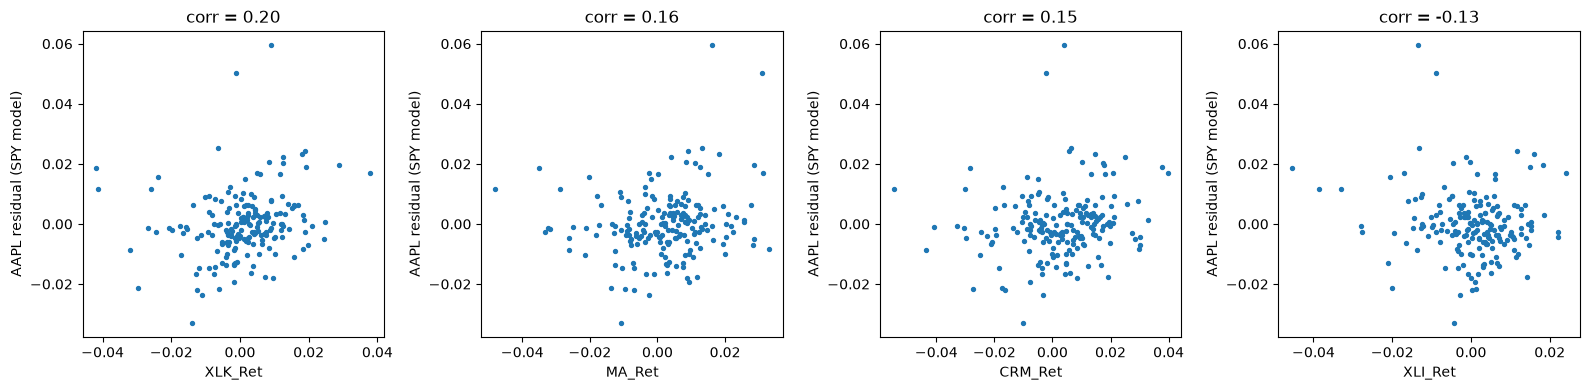

In [22]:
# Scatter plots of the top 4 candidates vs the residual
top4 = corr_with_resid.index[:4].to_list()
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axs, top4):
    ax.scatter(all_train_ret[c], resid, s=8)
    ax.set_xlabel(c)
    ax.set_ylabel("AAPL residual (SPY model)")
    ax.set_title("corr = {:.2f}".format(corr_with_resid[c]))
plt.tight_layout()
plt.show()

**EDA findings**

* XLK (technology sector ETF) is the most correlated with AAPL (0.76, higher than SPY at 0.65) **and** the most correlated with the SPY residual (0.20).
* Some tickers look strong in Step 3 but add little beyond SPY: e.g. MSFT (0.61 with AAPL, only 0.08 with the residual) and XLY (0.58 vs -0.01). They mostly move with the market.

## Experiments
Based on the EDA and on domain knowledge, we run three experiments:
1. **SPY**: the baseline model from Part 1
2. **SPY + XLK**: add the technology sector ETF (top of both EDA rankings)
3. **SPY + XLK + MSFT**: add Microsoft, Apple's closest large-cap tech peer

For each we report the betas, average 5-fold cross-validation score, in-sample RMSE and out-of-sample RMSE.

In [23]:
def run_experiment(name, features):
    '''
    Train a Linear Regression of AAPL returns on the given features,
    print the betas, CV score and RMSEs, and return the results as a dict
    '''
    X_tr, y_tr = all_train_ret[features], all_train_ret[["AAPL_Ret"]]
    X_te, y_te = all_test_ret[features],  all_test_ret[["AAPL_Ret"]]

    model = createModel()
    model.fit(X_tr.values, y_tr.values)

    result = {
        "experiment": name,
        "features":   ", ".join(features),
        "cv_avg":     compute_cross_val_avg(createModel(), X_tr, y_tr, 5),
        "rmse_in":    computeRMSE(y_tr, model.predict(X_tr.values)),
        "rmse_out":   computeRMSE(y_te, model.predict(X_te.values)),
    }

    print("Experiment:", name)
    print("  Intercept: {:.4f}".format(model.intercept_[0]))
    for f, b in zip(features, model.coef_[0]):
        print("  beta {:10s} = {:.3f}".format(f, b))
    print("  Avg 5-fold CV score = {:.3f}".format(result["cv_avg"]))
    print("  In-sample RMSE      = {:.4f}".format(result["rmse_in"]))
    print("  Out-of-sample RMSE  = {:.4f}".format(result["rmse_out"]))
    return result

results = []

### Experiment 1: SPY only (baseline from Part 1)
This is the model from the first part of the assignment. Every later model is compared against it.

In [24]:
results.append( run_experiment("1: SPY", ["SPY_Ret"]) )

Experiment: 1: SPY
  Intercept: 0.0011
  beta SPY_Ret    = 1.071
  Avg 5-fold CV score = 0.327
  In-sample RMSE      = 0.0111
  Out-of-sample RMSE  = 0.0152


### Experiment 2: SPY + XLK (technology sector ETF)
SPY captures the whole market, but Apple is a tech company. XLK tracks the technology sector,
so it should capture tech-specific moves that are diluted in SPY, where tech is only one of eleven sectors.

In [25]:
results.append( run_experiment("2: SPY + XLK", ["SPY_Ret", "XLK_Ret"]) )

Experiment: 2: SPY + XLK
  Intercept: 0.0006
  beta SPY_Ret    = -0.801
  beta XLK_Ret    = 1.536
  Avg 5-fold CV score = 0.548
  In-sample RMSE      = 0.0091
  Out-of-sample RMSE  = 0.0114


### Experiment 3: SPY + XLK + MSFT (peer stock)
Microsoft is Apple's closest large-cap peer: similar size, same sector and similar investors.
It may capture "mega-cap tech" moves that the sector ETF only partly reflects.

In [26]:
results.append( run_experiment("3: SPY + XLK + MSFT", ["SPY_Ret", "XLK_Ret", "MSFT_Ret"]) )

Experiment: 3: SPY + XLK + MSFT
  Intercept: 0.0009
  beta SPY_Ret    = -0.803
  beta XLK_Ret    = 2.038
  beta MSFT_Ret   = -0.428
  Avg 5-fold CV score = 0.583
  In-sample RMSE      = 0.0087
  Out-of-sample RMSE  = 0.0104


### Comparing the experiments

In [27]:
results_df = pd.DataFrame(results).set_index("experiment")
print(results_df.to_string())

                                       features    cv_avg   rmse_in  rmse_out
experiment                                                                   
1: SPY                                  SPY_Ret  0.326759  0.011071  0.015159
2: SPY + XLK                   SPY_Ret, XLK_Ret  0.548030  0.009088  0.011431
3: SPY + XLK + MSFT  SPY_Ret, XLK_Ret, MSFT_Ret  0.582555  0.008662  0.010355


In [28]:
# How the chosen features relate to AAPL and to each other
all_train_ret[["AAPL_Ret", "SPY_Ret", "XLK_Ret", "MSFT_Ret"]].corr().round(2)

,AAPL_Ret,SPY_Ret,XLK_Ret,MSFT_Ret
AAPL_Ret,1.00,0.65,0.76,0.61
SPY_Ret,0.65,1.00,0.93,0.84
XLK_Ret,0.76,0.93,1.00,0.90
MSFT_Ret,0.61,0.84,0.90,1.00


<BarContainer object of 3 artists>

Text(0.5, 1.0, 'Average 5-fold CV score (R^2)')

Text(0.5, 1.0, 'RMSE')

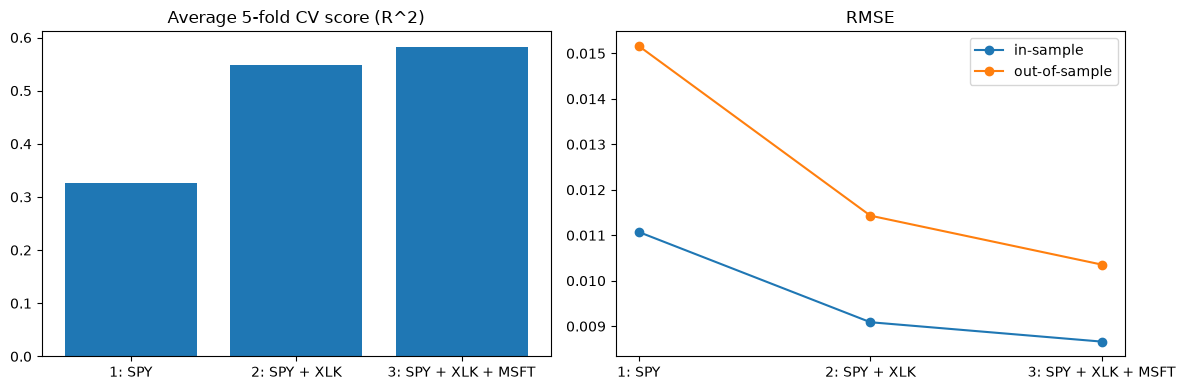

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(results_df.index, results_df["cv_avg"])
axs[0].set_title("Average 5-fold CV score (R^2)")
axs[1].plot(results_df.index, results_df["rmse_in"],  marker="o", label="in-sample")
axs[1].plot(results_df.index, results_df["rmse_out"], marker="o", label="out-of-sample")
axs[1].set_title("RMSE")
axs[1].legend()
plt.tight_layout()
plt.show()

### Extra check: does MSFT help on its own?
MSFT had a low residual correlation in Step 4, so we check whether it adds anything beyond SPY without XLK.

In [30]:
X_tr, y_tr = all_train_ret[["SPY_Ret", "MSFT_Ret"]], all_train_ret[["AAPL_Ret"]]
print("SPY + MSFT: Avg 5-fold CV score = {:.4f}  (SPY only: {:.4f})".format(
      compute_cross_val_avg(createModel(), X_tr, y_tr, 5), cross_val_avg))

SPY + MSFT: Avg 5-fold CV score = 0.3295  (SPY only: 0.3268)


## Why and how I chose the additional features

**EDA.** I computed each ticker's correlation with AAPL's return on the training data. XLK (technology
sector ETF) had the highest correlation (0.76), above SPY (0.65). Because many tickers are correlated with
AAPL simply because they move with the market, I also computed each ticker's correlation with the
residual of the SPY-only model (the part of AAPL's return SPY cannot explain). XLK ranked first here too (0.20).

**Experiment 1 (SPY only)** is the baseline from Part 1: CV score 0.327, in-sample RMSE 0.0111,
out-of-sample RMSE 0.0152.

**Experiment 2 (SPY + XLK).** Apple is a tech company, and XLK captures sector-wide moves that are
diluted in SPY. This was the largest improvement: CV score 0.548, in-sample RMSE 0.0091, out-of-sample
RMSE 0.0114. The SPY beta becomes negative (-0.80) because SPY and XLK are 0.93 correlated; the model
effectively becomes 0.74·SPY + 1.54·(XLK − SPY), i.e. market exposure plus a "tech beat the market" term.

**Experiment 3 (SPY + XLK + MSFT).** I added Microsoft as Apple's closest large-cap tech peer.
Results improved again: CV score 0.583, in-sample RMSE 0.0087, out-of-sample RMSE 0.0104.
However, MSFT had a low residual correlation (0.078), and SPY + MSFT alone barely beats SPY
(CV 0.330 vs 0.327). Its beta is negative (-0.43), which suggests MSFT is not helping as a peer: because
Apple and Microsoft are XLK's two largest holdings, subtracting MSFT from XLK isolates a component
closer to Apple's own return.

**Results.**

| | SPY only | SPY + XLK | SPY + XLK + MSFT |
|---|---|---|---|
| Avg 5-fold CV score | 0.327 | 0.548 | **0.583** |
| In-sample RMSE | 0.0111 | 0.0091 | **0.0087** |
| Out-of-sample RMSE | 0.0152 | 0.0114 | **0.0104** |

**Conclusion and caveats.** XLK is clearly the most valuable additional feature. The final model
(SPY + XLK + MSFT) reduces out-of-sample RMSE from 0.0152 to 0.0104. Two caveats: XLK contains AAPL
itself, so part of its predictive power comes from the target's own return; and the features are highly
correlated with each other (0.84–0.93), so individual betas are unstable and should not be interpreted
on their own.